# Finbert Sentiment Analysis

**Project:** Financial Planning & Analysis Intelligence Platform

**Notebook:** `04-finbert-sentiment-analysis.ipynb`

In [1]:
# ==========================================
# Notebook 04
# FinBERT Sentiment Analysis
# ==========================================

import pandas as pd
import numpy as np

from transformers import pipeline

In [2]:
financial_df = pd.read_csv("../data/financial_documents_cleaned.csv")

financial_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...


In [3]:
financial_df[["quarter", "earnings_call"]]

,quarter,earnings_call
0,2023-Q1,\n Demand remained strong across enterp...
1,2023-Q2,\n Enterprise adoption accelerated.\n ...
2,2023-Q3,\n Customer demand exceeded expectation...
3,2023-Q4,\n Record quarter performance.\n ...
4,2024-Q1,\n Strong start to the fiscal year driv...
5,2024-Q2,\n New AI-driven product modules saw re...
6,2024-Q3,\n European expansion is yielding solid...
7,2024-Q4,"\n An exceptional finish to 2024, cross..."
8,2025-Q1,\n We carried the strong closing moment...
9,2025-Q2,\n Our SaaS migration is officially com...


In [4]:
finbert = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    truncation=True,
)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\vinna\.cache\huggingface\hub\models--ProsusAI--finbert. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [5]:
sample_text = """

Demand remained strong.

Management expects continued growth.

Margins improved significantly.

"""

finbert(sample_text)

[{'label': 'positive', 'score': 0.9620582461357117}]

In [6]:
def analyze_financial_sentiment(text):

    result = finbert(str(text))[0]

    return {"sentiment": result["label"], "confidence": float(result["score"])}

In [7]:
analyze_financial_sentiment(financial_df.iloc[0]["earnings_call"])

{'sentiment': 'positive', 'confidence': 0.9561673402786255}

In [8]:
sentiment_results = []

for _, row in financial_df.iterrows():

    result = analyze_financial_sentiment(row["earnings_call"])

    sentiment_results.append(
        {
            "ticker": row["ticker"],
            "quarter": row["quarter"],
            "sentiment": result["sentiment"],
            "confidence": result["confidence"],
            "revenue": row["revenue_million"],
        }
    )

In [9]:
sentiment_df = pd.DataFrame(sentiment_results)

sentiment_df

,ticker,quarter,sentiment,confidence,revenue
0,ABC,2023-Q1,positive,0.956167,120
1,ABC,2023-Q2,positive,0.957692,128
2,ABC,2023-Q3,positive,0.951876,138
3,ABC,2023-Q4,positive,0.956653,150
4,ABC,2024-Q1,positive,0.922371,158
5,ABC,2024-Q2,positive,0.921203,167
6,ABC,2024-Q3,positive,0.919702,174
7,ABC,2024-Q4,positive,0.952842,190
8,ABC,2025-Q1,negative,0.740657,198
9,ABC,2025-Q2,positive,0.953374,210


In [10]:
sentiment_df["sentiment"].value_counts()

sentiment
positive    11
negative     1
Name: count, dtype: int64

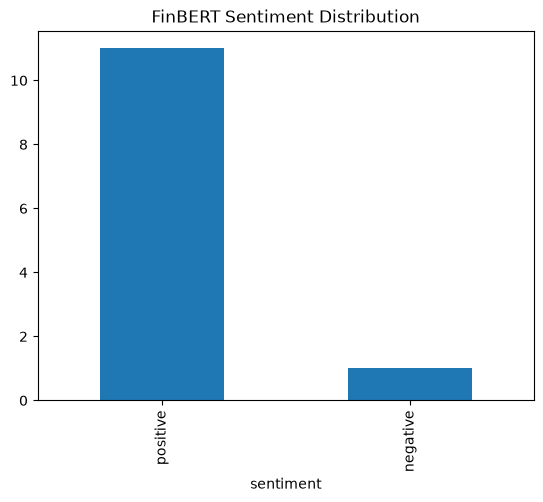

In [11]:
import matplotlib.pyplot as plt

sentiment_df["sentiment"].value_counts().plot(kind="bar")

plt.title("FinBERT Sentiment Distribution")

plt.show()

In [12]:
sentiment_mapping = {"positive": 1, "neutral": 0, "negative": -1}

In [13]:
sentiment_df["sentiment_score"] = sentiment_df["sentiment"].map(sentiment_mapping)

In [14]:
sentiment_df

,ticker,quarter,sentiment,confidence,revenue,sentiment_score
0,ABC,2023-Q1,positive,0.956167,120,1
1,ABC,2023-Q2,positive,0.957692,128,1
2,ABC,2023-Q3,positive,0.951876,138,1
3,ABC,2023-Q4,positive,0.956653,150,1
4,ABC,2024-Q1,positive,0.922371,158,1
5,ABC,2024-Q2,positive,0.921203,167,1
6,ABC,2024-Q3,positive,0.919702,174,1
7,ABC,2024-Q4,positive,0.952842,190,1
8,ABC,2025-Q1,negative,0.740657,198,-1
9,ABC,2025-Q2,positive,0.953374,210,1


In [15]:
sentiment_df["weighted_sentiment"] = (
    sentiment_df["sentiment_score"] * sentiment_df["confidence"]
)

In [16]:
sentiment_df[["quarter", "sentiment", "confidence", "weighted_sentiment"]]

,quarter,sentiment,confidence,weighted_sentiment
0,2023-Q1,positive,0.956167,0.956167
1,2023-Q2,positive,0.957692,0.957692
2,2023-Q3,positive,0.951876,0.951876
3,2023-Q4,positive,0.956653,0.956653
4,2024-Q1,positive,0.922371,0.922371
5,2024-Q2,positive,0.921203,0.921203
6,2024-Q3,positive,0.919702,0.919702
7,2024-Q4,positive,0.952842,0.952842
8,2025-Q1,negative,0.740657,-0.740657
9,2025-Q2,positive,0.953374,0.953374


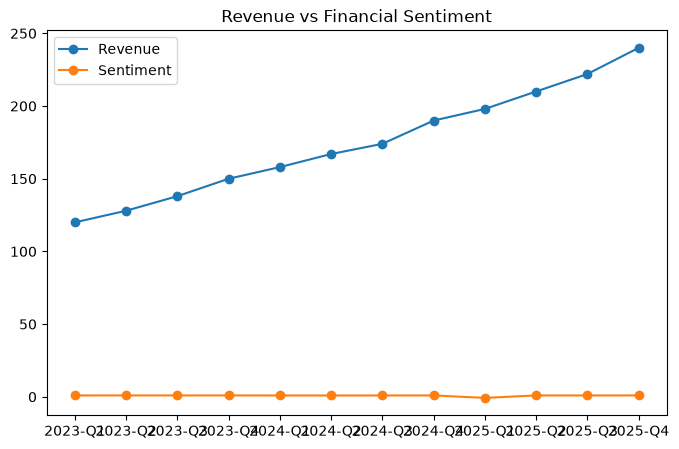

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(sentiment_df["quarter"], sentiment_df["revenue"], marker="o", label="Revenue")

plt.plot(
    sentiment_df["quarter"],
    sentiment_df["weighted_sentiment"],
    marker="o",
    label="Sentiment",
)

plt.legend()

plt.title("Revenue vs Financial Sentiment")

plt.show()

In [18]:
sentiment_df["weighted_sentiment"].mean()

0.8015629798173904

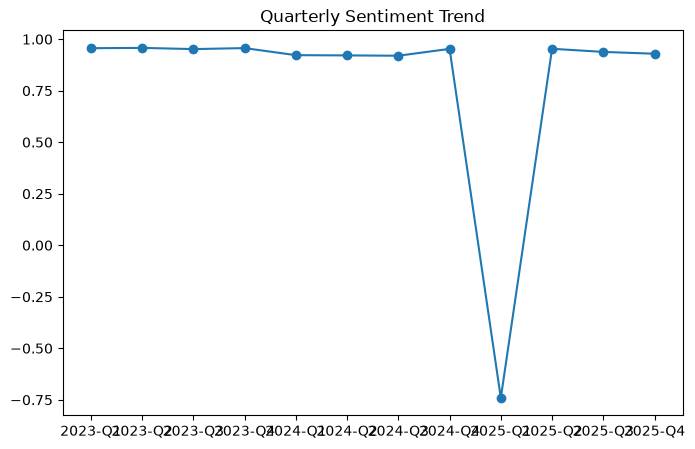

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(sentiment_df["quarter"], sentiment_df["weighted_sentiment"], marker="o")

plt.title("Quarterly Sentiment Trend")

plt.show()

In [20]:
financial_sentiment_df = pd.merge(
    financial_df,
    sentiment_df[["quarter", "sentiment", "confidence", "weighted_sentiment"]],
    on="quarter",
)

In [ ]:
financial_sentiment_df.head()

,ticker,quarter,revenue_million,gross_margin_pct,operating_income_million,net_income_million,eps,earnings_call,risk_factors,mda_section,combined_text,clean_text,character_count,sentences,chunks,sentiment,confidence,weighted_sentiment
0,ABC,2023-Q1,120,58,22,16,1.20,\n Demand remained strong across enterp...,\n Inflation remains a concern.\n ...,\n Management believes demand trends re...,\n Demand remained strong across enterp...,Demand remained strong across enterprise custo...,299,['Demand remained strong across enterprise cus...,['Demand remained strong across enterprise cus...,positive,0.956167,0.956167
1,ABC,2023-Q2,128,60,25,18,1.35,\n Enterprise adoption accelerated.\n ...,\n Competitive pressure exists.\n ...,\n New product launches contributed pos...,\n Enterprise adoption accelerated.\n ...,Enterprise adoption accelerated. Pricing press...,239,"['Enterprise adoption accelerated.', 'Pricing ...",['Enterprise adoption accelerated. Pricing pre...,positive,0.957692,0.957692
2,ABC,2023-Q3,138,61,28,21,1.52,\n Customer demand exceeded expectation...,\n Geopolitical uncertainty remains.\n ...,\n Strong customer growth across region...,\n Customer demand exceeded expectation...,Customer demand exceeded expectations. Supply ...,269,"['Customer demand exceeded expectations.', 'Su...",['Customer demand exceeded expectations. Suppl...,positive,0.951876,0.951876
3,ABC,2023-Q4,150,63,32,24,1.72,\n Record quarter performance.\n ...,\n Macroeconomic slowdown remains possi...,\n Revenue growth exceeded internal exp...,\n Record quarter performance.\n ...,Record quarter performance. Management expects...,260,"['Record quarter performance.', 'Management ex...",['Record quarter performance. Management expec...,positive,0.956653,0.956653
4,ABC,2024-Q1,158,62,34,26,1.85,\n Strong start to the fiscal year driv...,\n Increased cyber security threats req...,\n Gross margin slightly contracted due...,\n Strong start to the fiscal year driv...,Strong start to the fiscal year driven by ente...,460,['Strong start to the fiscal year driven by en...,['Strong start to the fiscal year driven by en...,positive,0.922371,0.922371


In [ ]:
financial_sentiment_df["chunks"]

0     ['Demand remained strong across enterprise cus...
1     ['Enterprise adoption accelerated. Pricing pre...
2     ['Customer demand exceeded expectations. Suppl...
3     ['Record quarter performance. Management expec...
4     ['Strong start to the fiscal year driven by en...
5     ['New AIdriven product modules saw record adop...
6     ['European expansion is yielding solid initial...
7     ['An exceptional finish to 2024, crossing hist...
8     ['We carried the strong closing momentum of la...
9     ['Our SaaS migration is officially complete, d...
10    ['APAC region performance exceeded our threeye...
11    ['A monumental year for ABC, closing out 2025 ...
Name: chunks, dtype: object

In [25]:
financial_sentiment_df.to_csv("../data/financial_sentiment_dataset.csv", index=False)

In [28]:
sentiment_df.to_csv("../data/financial_sentiment_scores.csv", index=False)

In [29]:
saved_df = pd.read_csv("../data/financial_sentiment_scores.csv")

saved_df.head()

,ticker,quarter,sentiment,confidence,revenue,sentiment_score,weighted_sentiment
0,ABC,2023-Q1,positive,0.956167,120,1,0.956167
1,ABC,2023-Q2,positive,0.957692,128,1,0.957692
2,ABC,2023-Q3,positive,0.951876,138,1,0.951876
3,ABC,2023-Q4,positive,0.956653,150,1,0.956653
4,ABC,2024-Q1,positive,0.922371,158,1,0.922371
